#PART A : Dynamic Goal-Based Agent for Warehouse Logistics Optimization



## Q1: Warehouse Representation
### First, we need to create and visualize the warehouse environment:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random
from collections import deque

# Set random seed for reproducibility
np.random.seed(42)
random.seed(42)

# Define warehouse parameters
N, M = 8, 8  # Grid dimensions
num_packages = 3
num_obstacles = 5

# Create empty warehouse grid
# 0: empty, 1: obstacle, 2: package, 3: drop-off, 4: robot
warehouse = np.zeros((N, M), dtype=int)

# Place robot at starting position (loading dock)
robot_pos = (0, 0)
warehouse[robot_pos] = 4

# Place obstacles randomly
obstacle_positions = []
while len(obstacle_positions) < num_obstacles:
    x, y = random.randint(0, N-1), random.randint(0, M-1)
    if warehouse[x, y] == 0 and (x, y) != robot_pos:
        warehouse[x, y] = 1
        obstacle_positions.append((x, y))

# Place packages randomly
package_positions = []
while len(package_positions) < num_packages:
    x, y = random.randint(0, N-1), random.randint(0, M-1)
    if warehouse[x, y] == 0:
        warehouse[x, y] = 2
        package_positions.append((x, y))

# Place drop-off points randomly
dropoff_positions = []
while len(dropoff_positions) < num_packages:
    x, y = random.randint(0, N-1), random.randint(0, M-1)
    if warehouse[x, y] == 0:
        warehouse[x, y] = 3
        dropoff_positions.append((x, y))

### Function to visualise the warehouse

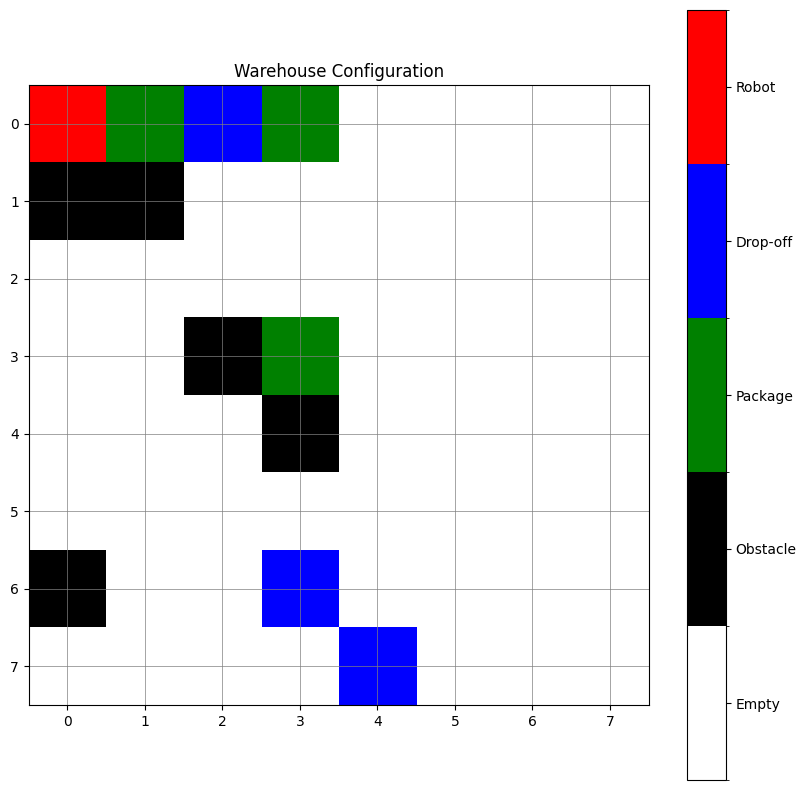

Robot starting position: (0, 0)
Package positions: [(0, 1), (3, 3), (0, 3)]
Drop-off positions: [(6, 3), (7, 4), (0, 2)]
Obstacle positions: [(1, 0), (4, 3), (3, 2), (1, 1), (6, 0)]


In [ ]:
def visualize_warehouse(grid):
    plt.figure(figsize=(10, 10))
    cmap = plt.cm.colors.ListedColormap(['white', 'black', 'green', 'blue', 'red'])
    bounds = [0, 1, 2, 3, 4, 5]
    norm = plt.cm.colors.BoundaryNorm(bounds, cmap.N)
    plt.imshow(grid, cmap=cmap, norm=norm)

    # Create colorbar with custom tick positions and labels
    cbar = plt.colorbar(ticks=[0.5, 1.5, 2.5, 3.5, 4.5])
    cbar.ax.set_yticklabels(['Empty', 'Obstacle', 'Package', 'Drop-off', 'Robot'])  # Set tick labels

    plt.grid(True, which='both', color='gray', linestyle='-', linewidth=0.5)
    plt.title('Warehouse Configuration')
    plt.show()

# Display initial warehouse configuration
visualize_warehouse(warehouse)

print(f"Robot starting position: {robot_pos}")
print(f"Package positions: {package_positions}")
print(f"Drop-off positions: {dropoff_positions}")
print(f"Obstacle positions: {obstacle_positions}")

##Q2: Goal-Based Agent Implementation
Next, we implement the agent using Breadth-First Search (BFS) for path finding

In [ ]:
def bfs_path(grid, start, goal):
    """Find path using BFS from start to goal"""
    queue = deque([(start, [])])
    visited = set([start])
    n, m = grid.shape

    # Possible movements (up, right, down, left)
    directions = [(-1, 0), (0, 1), (1, 0), (0, -1)]

    while queue:
        (x, y), path = queue.popleft()

        # If reached the goal
        if (x, y) == goal:
            return path + [(x, y)]

        # Try all four directions
        for dx, dy in directions:
            nx, ny = x + dx, y + dy

            # Check if the new position is valid
            if 0 <= nx < n and 0 <= ny < m and grid[nx, ny] != 1 and (nx, ny) not in visited:
                queue.append(((nx, ny), path + [(x, y)]))
                visited.add((nx, ny))

    # No path found
    return None


 ### Simulates the agent delivering all packages


In [ ]:
def deliver_packages(warehouse, robot_pos, package_positions, dropoff_positions):
    n, m = warehouse.shape
    current_pos = robot_pos
    total_cost = 0
    total_reward = 0
    total_penalties = 0
    delivery_sequence = []
    paths = []

    # Make copy of the warehouse for simulation
    warehouse_copy = warehouse.copy()

    # Create package-dropoff mapping
    package_to_dropoff = dict(zip(package_positions, dropoff_positions))

    # Process each package
    for package_pos, dropoff_pos in package_to_dropoff.items():
        # Find path from current position to package
        path_to_package = bfs_path(warehouse_copy, current_pos, package_pos)

        if path_to_package:
            # Add path to package to full path
            paths.append(path_to_package)

            # Update current position and movement cost
            current_pos = package_pos
            total_cost += len(path_to_package) - 1  # -1 because start position is included

            # Mark package as picked up (replace with empty space)
            warehouse_copy[package_pos] = 0

            # Find path from package to its drop-off location
            path_to_dropoff = bfs_path(warehouse_copy, current_pos, dropoff_pos)

            if path_to_dropoff:
                # Add path to dropoff to full path
                paths.append(path_to_dropoff)

                # Update current position and costs/rewards
                current_pos = dropoff_pos
                total_cost += len(path_to_dropoff) - 1  # -1 because start position is included
                total_reward += 10  # Reward for successful delivery

                # Add to delivery sequence
                delivery_sequence.append((package_pos, dropoff_pos))
            else:
                print(f"No path found from package {package_pos} to dropoff {dropoff_pos}")
        else:
            print(f"No path found from {current_pos} to package {package_pos}")

    return {
        'paths': paths,
        'total_cost': total_cost,
        'total_reward': total_reward,
        'total_penalties': total_penalties,
        'final_score': total_reward - total_cost - total_penalties,
        'delivery_sequence': delivery_sequence
    }

# Run the simulation
results = deliver_packages(warehouse, robot_pos, package_positions, dropoff_positions)

# Print results
print("\nDelivery Results:")
print(f"Delivery Sequence: {results['delivery_sequence']}")
print(f"Total Movement Cost: {results['total_cost']}")
print(f"Total Delivery Reward: {results['total_reward']}")
print(f"Total Obstacle Penalties: {results['total_penalties']}")
print(f"Final Score: {results['final_score']}")


Delivery Results:
Delivery Sequence: [((0, 1), (6, 3)), ((3, 3), (7, 4)), ((0, 3), (0, 2))]
Total Movement Cost: 30
Total Delivery Reward: 30
Total Obstacle Penalties: 0
Final Score: 0


##Q3: Execution and Results
### Now we run the simulation and display the results

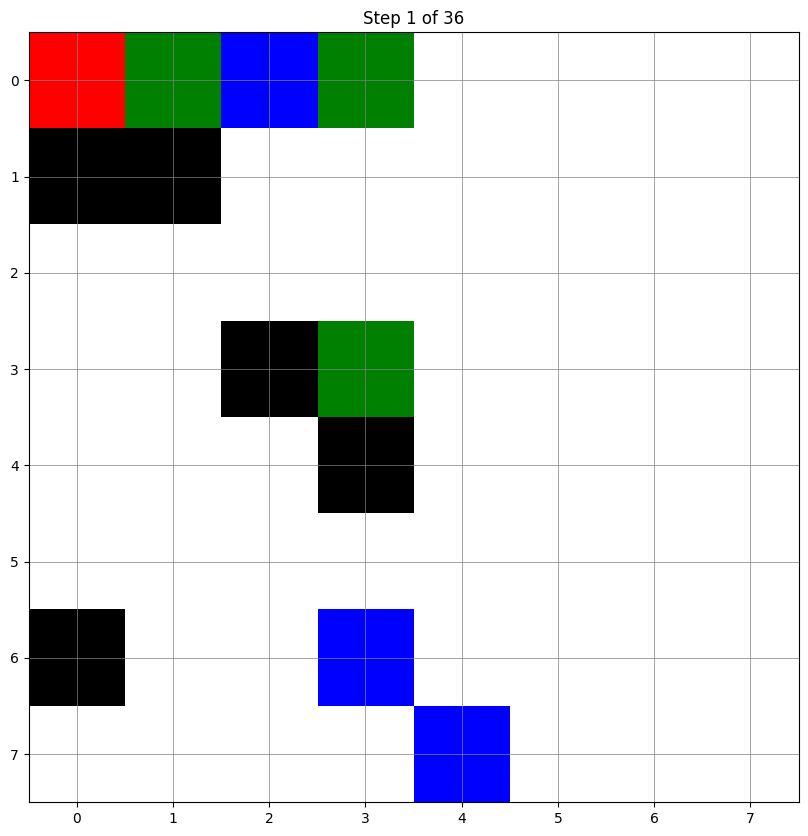

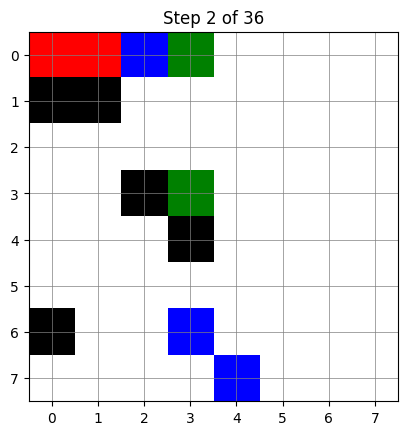

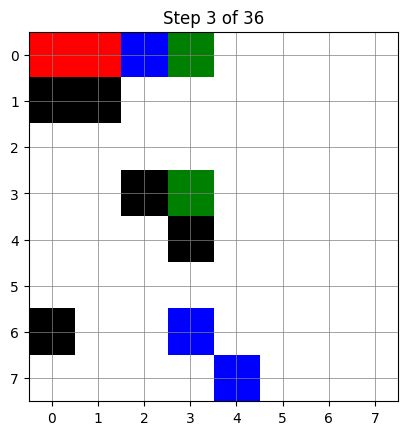

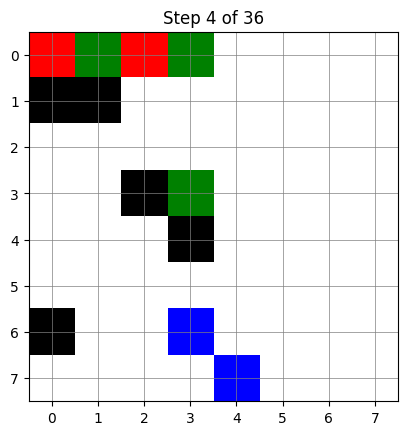

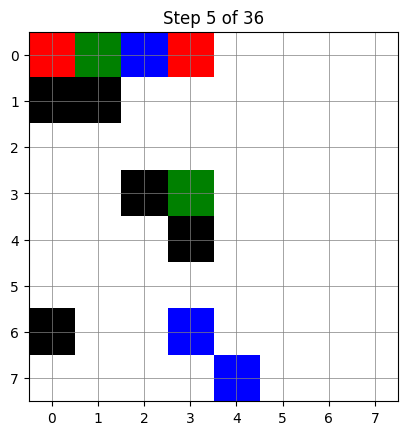

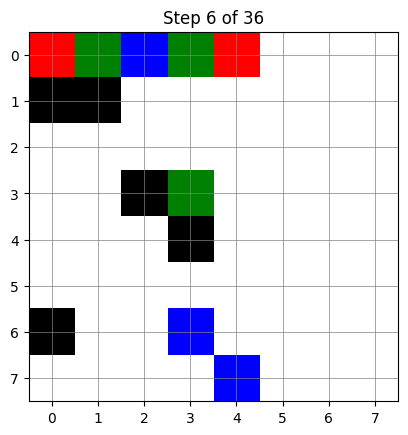

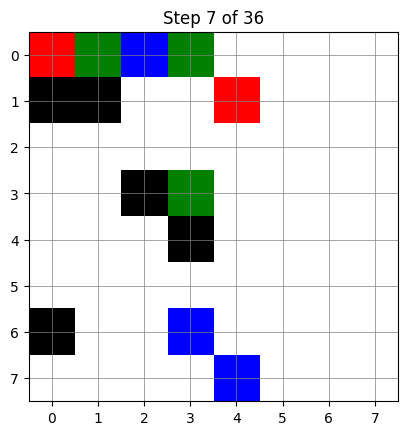

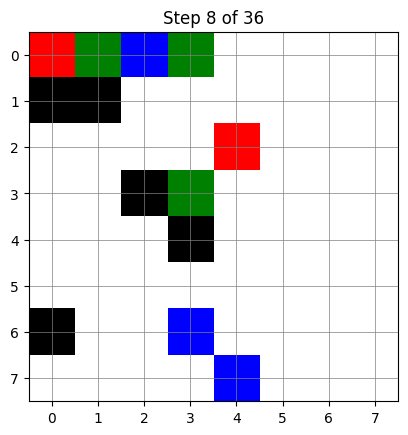

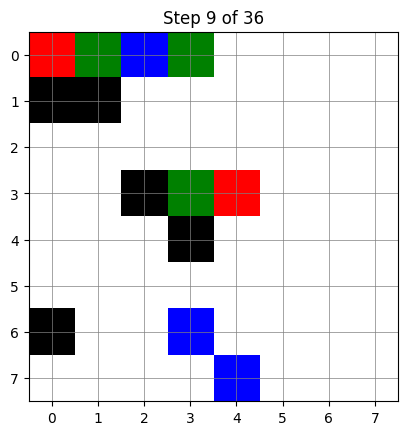

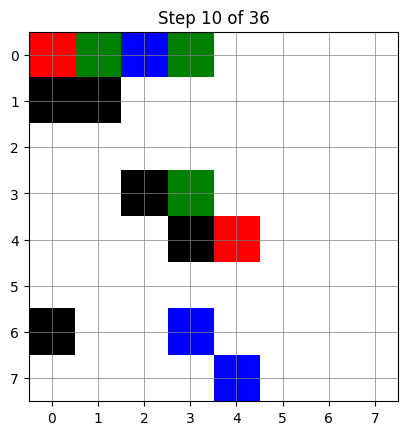

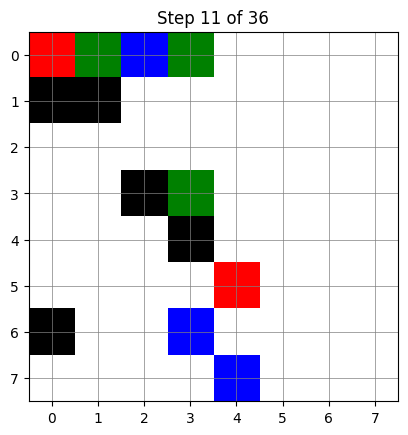

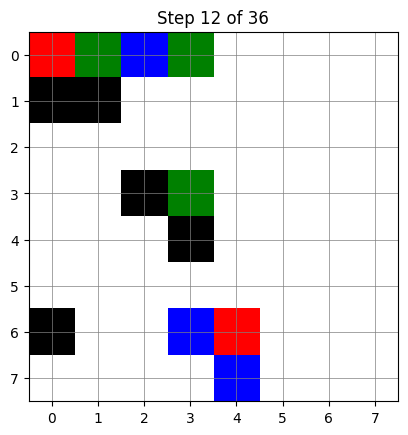

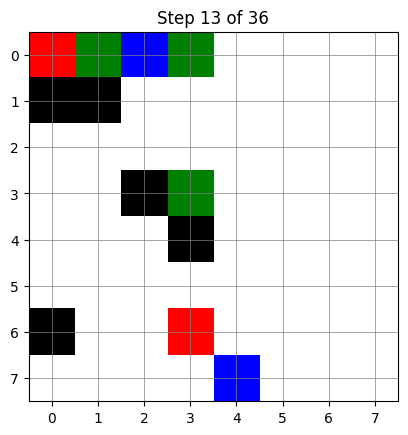

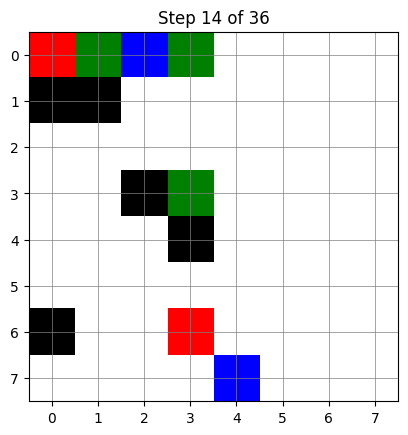

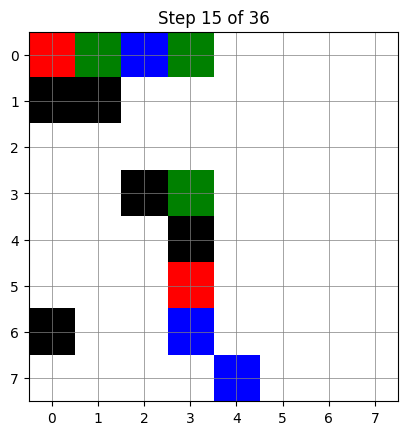

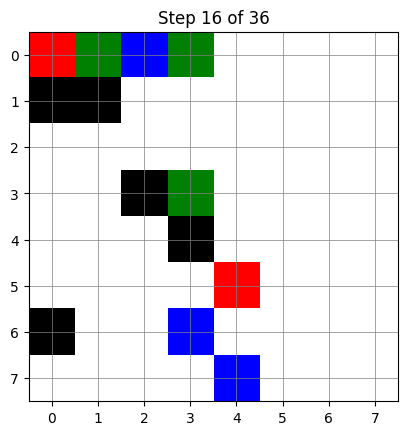

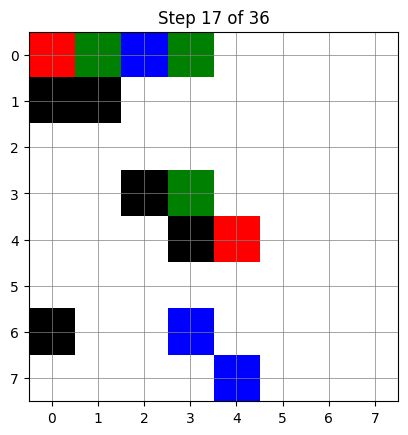

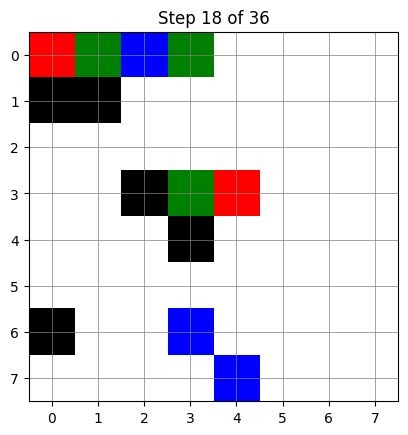

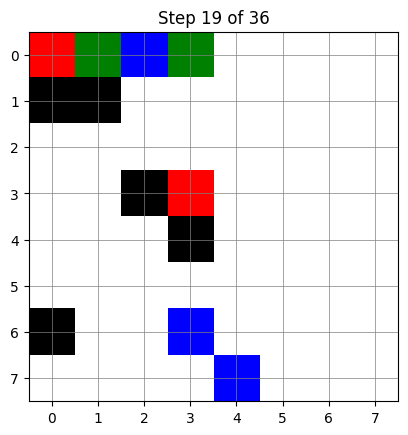

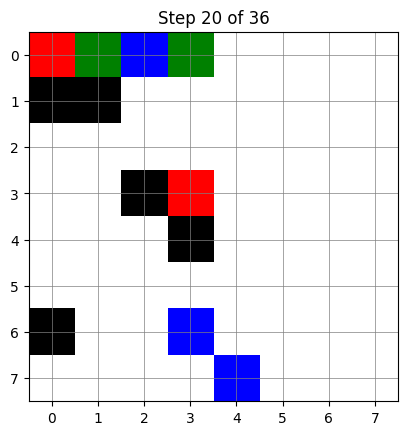

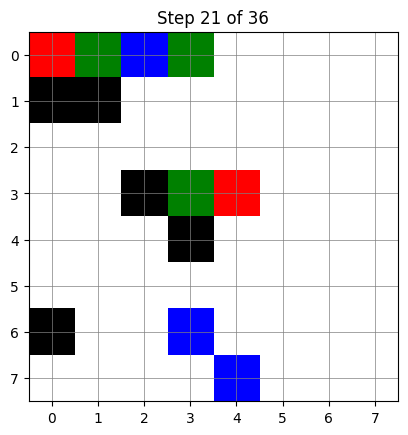

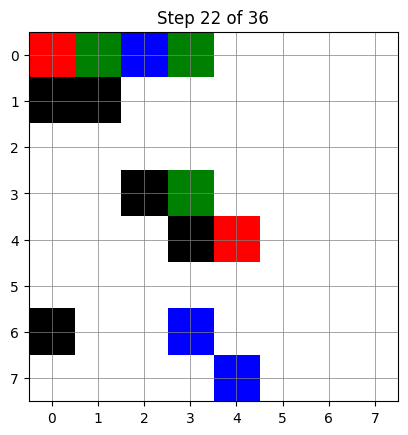

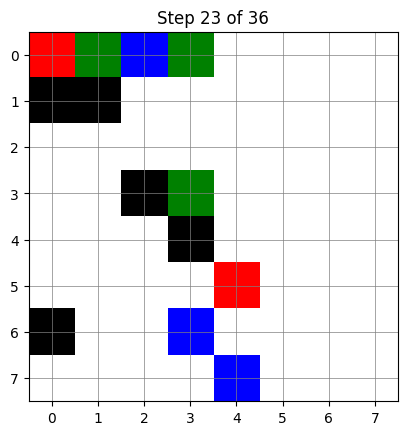

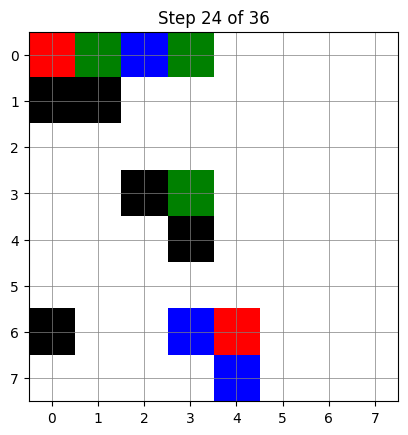

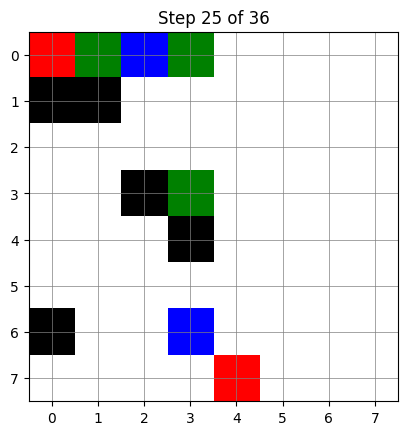

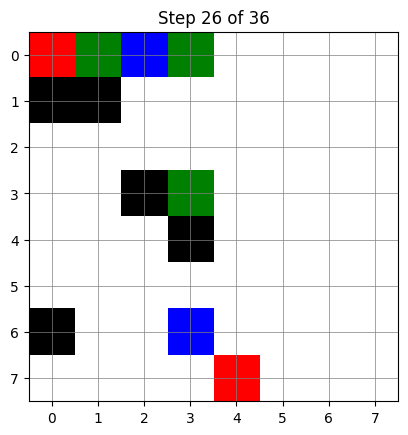

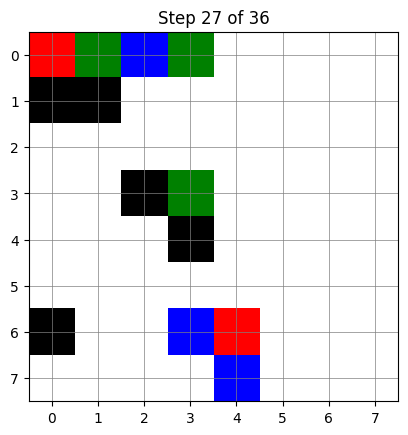

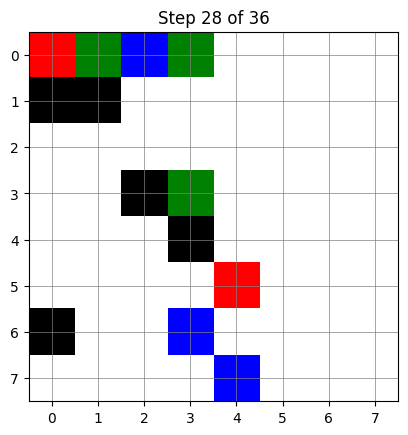

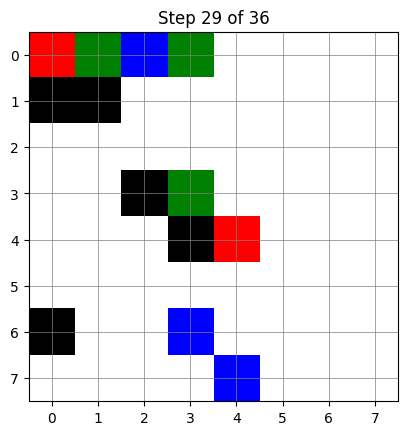

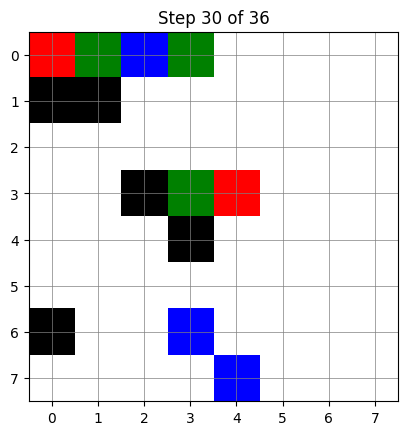

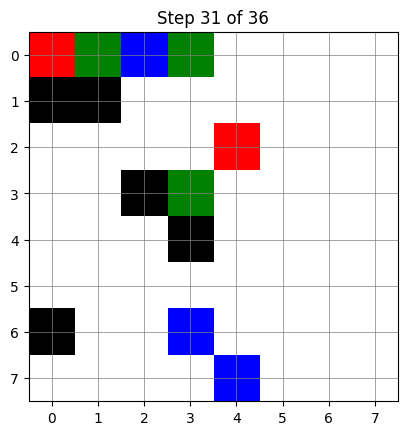

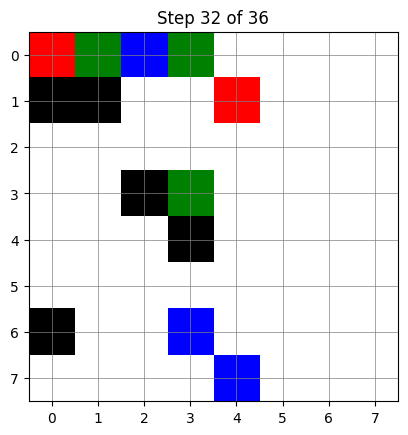

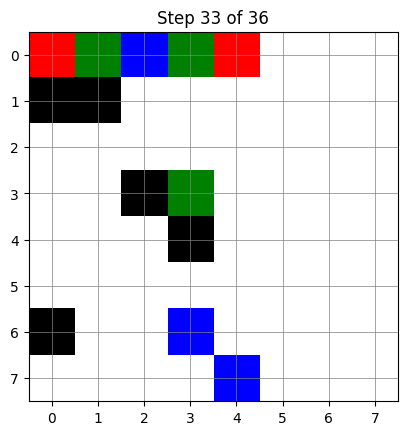

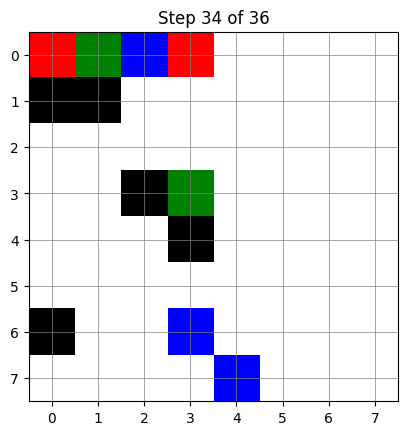

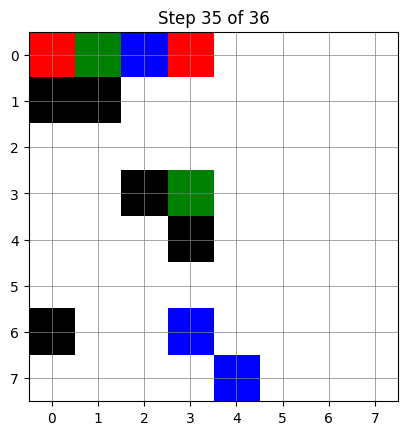

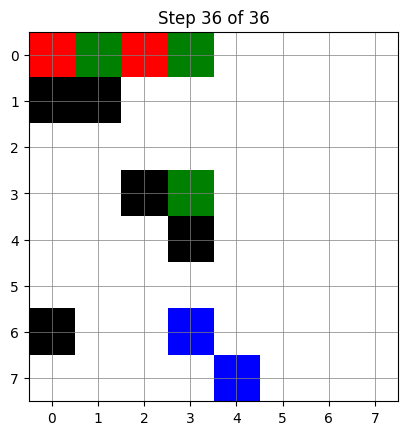

In [ ]:
# Animate the path (simplified version)
def animate_path(grid, paths):
    """Visualize the path taken by the agent"""
    grid_copy = grid.copy()

    plt.figure(figsize=(10, 10))

    # Combine all paths
    all_steps = []
    for path in paths:
        all_steps.extend(path)

    # Mark path on grid
    for i, (x, y) in enumerate(all_steps):
        temp_grid = grid_copy.copy()
        temp_grid[x, y] = 4  # Mark robot position

        plt.clf()
        cmap = plt.cm.colors.ListedColormap(['white', 'black', 'green', 'blue', 'red'])
        bounds = [0, 1, 2, 3, 4, 5]
        norm = plt.cm.colors.BoundaryNorm(bounds, cmap.N)
        plt.imshow(temp_grid, cmap=cmap, norm=norm)
        plt.grid(True, which='both', color='gray', linestyle='-', linewidth=0.5)
        plt.title(f'Step {i+1} of {len(all_steps)}')
        plt.pause(0.1)

    plt.show()

# Visualize the agent's path
animate_path(warehouse, results['paths'])


#PART B : Optimal Meetup Location Search Problem

In [ ]:
!pip install ge

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx
import pandas as pd
import time
import heapq
from collections import defaultdict
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from IPython.display import display
from google.colab import drive

### Set matplotlib parameters for better visualization


In [ ]:
plt.rcParams['figure.figsize'] = [15, 10]
plt.rcParams['font.size'] = 12

### Load and prepare the geospatial data

Load district data from GeoJSON files for Kerala, Karnataka, and Maharashtra


In [ ]:
def load_data():
    # Define state files to load
    state_files = {
        'Kerala': ['kerala_district.json'],
        'Karnataka': ['karnataka_district.json'],
        'Maharashtra': ['maharashtra_district.json']
    }

    # Store successfully loaded data
    state_gdfs = {}

    # Load each state's data
    for state_name, file_paths in state_files.items():
        for file_path in file_paths:
            try:
                gdf = gpd.read_file(file_path)
                # Add state name if not present
                if 'st_nm' not in gdf.columns:
                    gdf['st_nm'] = state_name
                state_gdfs[state_name] = gdf
                print(f"{state_name} districts loaded: {len(gdf)} districts")
                break  # Successfully loaded, move to next state
            except Exception as e:
                print(f"Error loading {state_name} data from {file_path}: {e}")

    # Check if any data was loaded
    if not state_gdfs:
        raise ValueError("No state data could be loaded successfully")

    # Combine all state data
    combined_gdf = pd.concat(list(state_gdfs.values()))
    print(f"Total districts: {len(combined_gdf)}")
    print(f"States represented: {combined_gdf['st_nm'].unique()}")

    # Ensure consistent coordinate reference system
    if combined_gdf.crs is None:
        combined_gdf = combined_gdf.set_crs(epsg=4326)

    # Standardize district column
    if 'district' not in combined_gdf.columns:
        # Try to find the district column from common alternatives
        district_column_options = ['district', 'District', 'DISTRICT', 'dist_name', 'DIST_NAME', 'dt_name', 'DT_NAME']
        found = False
        for col in district_column_options:
            if col in combined_gdf.columns:
                combined_gdf['district'] = combined_gdf[col]
                print(f"Using {col} as the district column")
                found = True
                break

        if not found:
            # If no matching column found, use index as district name
            print("District column not found. Creating one with a default name.")
            combined_gdf['district'] = combined_gdf.index.astype(str)

    # Calculate centroids for distance calculations
    try:
        combined_gdf['centroid'] = combined_gdf.geometry.centroid
    except Exception:
        # Handle invalid geometries
        combined_gdf['centroid'] = combined_gdf.geometry.buffer(0).centroid

    combined_gdf['lon'] = combined_gdf.centroid.x
    combined_gdf['lat'] = combined_gdf.centroid.y

    return combined_gdf

### Calculate the great circle distance between two points on the Earth

    Args:
        lat1, lon1: Latitude and longitude of point 1 (in degrees)
        lat2, lon2: Latitude and longitude of point 2 (in degrees)

    Returns:
        Distance in kilometers

In [ ]:
def haversine_distance(lat1, lon1, lat2, lon2):
    # Convert latitude and longitude from degrees to radians
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    # Haversine formula
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    r = 6371  # Radius of Earth in kilometers
    return c * r

### Create a graph representing the city network

    Args:
        combined_gdf: GeoDataFrame with district data
        distance_threshold: Maximum distance between adjacent districts in km
        required_districts: Optional list of districts that must be included
        
    Returns:
        NetworkX graph with districts as nodes and distances as edge weights

In [ ]:
def create_city_network(combined_gdf, distance_threshold=150, required_districts=None):
    if required_districts is None:
        required_districts = []

    # Create graph and add nodes
    G = nx.Graph()
    districts_added = add_district_nodes(G, combined_gdf)

    # Check if required districts are present
    check_required_districts(districts_added, required_districts)

    # Set up thresholds for connectivity
    intra_state_threshold = distance_threshold       # Within same state
    inter_state_threshold = distance_threshold * 1.2  # Between states

    # Add edges between districts
    add_intra_state_edges(G, combined_gdf, intra_state_threshold)
    add_inter_state_edges(G, combined_gdf, inter_state_threshold)

    # Ensure required districts can reach each other
    connect_required_districts(G, combined_gdf, required_districts)

    # Make sure the graph is connected
    ensure_connected_graph(G, combined_gdf, required_districts)

    # Final check for missing districts
    missing = [d for d in required_districts if d not in G]
    if missing:
        print(f"Warning: After processing, these districts are still missing: {missing}")

    return G

### Add district nodes to the graph with position and state info


In [ ]:
def add_district_nodes(G, gdf):
    districts_added = []
    for _, row in gdf.iterrows():
        G.add_node(row['district'],
                  pos=(row['lon'], row['lat']),
                  state=row['st_nm'])
        districts_added.append(row['district'])
    print(f"Added {len(districts_added)} districts to graph")
    return districts_added


### Check if all required districts are in the graph

In [ ]:
def check_required_districts(districts_added, required_districts):
    missing_districts = [d for d in required_districts if d not in districts_added]
    if missing_districts:
        print(f"Warning: The following required districts are missing: {missing_districts}")
        # Find similar district names as possible alternatives
        for missing in missing_districts:
            similar_districts = [d for d in districts_added
                              if missing.lower() in d.lower() or d.lower() in missing.lower()]
            if similar_districts:
                print(f"Similar districts found for {missing}: {similar_districts}")

### Add edges between districts within the same state

In [ ]:
def add_intra_state_edges(G, gdf, threshold):
    edges_added = 0
    for state in gdf['st_nm'].unique():
        state_gdf = gdf[gdf['st_nm'] == state]
        # Connect districts within this state
        for idx1, row1 in state_gdf.iterrows():
            for idx2, row2 in state_gdf.iterrows():
                if idx1 != idx2:
                    dist = haversine_distance(row1['lat'], row1['lon'],
                                            row2['lat'], row2['lon'])
                    if dist < threshold:
                        G.add_edge(row1['district'], row2['district'], weight=dist)
                        edges_added += 1
    print(f"Added {edges_added} edges between districts within the same state")

### Add edges between districts across state borders

In [ ]:
def add_inter_state_edges(G, gdf, threshold):
    edges_added = 0
    states = gdf['st_nm'].unique()
    for i, state1 in enumerate(states):
        for state2 in states[i+1:]:  # Only consider each state pair once
            state1_gdf = gdf[gdf['st_nm'] == state1]
            state2_gdf = gdf[gdf['st_nm'] == state2]

            # Connect districts across state borders
            for _, row1 in state1_gdf.iterrows():
                for _, row2 in state2_gdf.iterrows():
                    dist = haversine_distance(row1['lat'], row1['lon'],
                                            row2['lat'], row2['lon'])
                    if dist < threshold:
                        G.add_edge(row1['district'], row2['district'], weight=dist)
                        edges_added += 1
    print(f"Added {edges_added} edges between districts across state borders")

### Make sure required districts have connections to other states

In [ ]:
def connect_required_districts(G, gdf, required_districts):
    for district in required_districts:
        if district not in G:
            continue

        # Check if district is already connected to other required districts
        if any(nx.has_path(G, district, other) for other in required_districts
               if other != district and other in G):
            continue

        # Find closest district from a different state
        district_row = gdf[gdf['district'] == district].iloc[0]
        district_state = district_row['st_nm']

        # Get districts from other states
        other_state_districts = [node for node in G.nodes()
                               if G.nodes[node]['state'] != district_state]

        # Find closest district
        closest_district = None
        best_distance = float('inf')

        for other_district in other_state_districts:
            other_row = gdf[gdf['district'] == other_district].iloc[0]
            dist = haversine_distance(district_row['lat'], district_row['lon'],
                                    other_row['lat'], other_row['lon'])
            if dist < best_distance:
                best_distance = dist
                closest_district = other_district

        if closest_district:
            G.add_edge(district, closest_district, weight=best_distance)
            print(f"Added cross-state connection between {district} and {closest_district} ({best_distance:.2f} km)")

In [ ]:
def ensure_connected_graph(G, gdf, required_districts):
    """Ensure the graph is connected while preserving required districts."""
    if nx.is_connected(G):
        print(f"Graph is fully connected with {len(G.nodes())} districts")
        return

    components = list(nx.connected_components(G))
    print(f"Graph has {len(components)} connected components")

    if required_districts:
        connect_components_with_required_districts(G, gdf, components, required_districts)
    else:
        # Use largest component if no required districts specified
        largest_cc = max(components, key=len)
        G = G.subgraph(largest_cc).copy()
        print(f"Using largest connected component with {len(G.nodes())} districts")

### Connect components containing required districts

In [ ]:
def connect_components_with_required_districts(G, gdf, components, required_districts):
    # Find which components contain required districts
    required_components = []
    for i, component in enumerate(components):
        for district in required_districts:
            if district in component:
                if i not in required_components:
                    required_components.append(i)
                break

    # Connect components with required districts
    if len(required_components) > 1:
        for i in range(len(required_components)-1):
            comp1 = list(components[required_components[i]])
            comp2 = list(components[required_components[i+1]])
            connect_component_pair(G, gdf, comp1, comp2)

    # Check if all required districts are connected
    connected_required = set()
    for district in required_districts:
        if district in G:
            for r in required_districts:
                if r != district and r in G and nx.has_path(G, district, r):
                    connected_required.add(district)
                    connected_required.add(r)

    # If some required districts aren't connected, add direct paths
    if connected_required and len(connected_required) < len([d for d in required_districts if d in G]):
        print("Warning: Not all required districts are connected")
        existing_required = [d for d in required_districts if d in G]
        if len(existing_required) > 1:
            for i in range(len(existing_required)-1):
                if not nx.has_path(G, existing_required[i], existing_required[i+1]):
                    d1_row = gdf[gdf['district'] == existing_required[i]].iloc[0]
                    d2_row = gdf[gdf['district'] == existing_required[i+1]].iloc[0]
                    dist = haversine_distance(d1_row['lat'], d1_row['lon'],
                                            d2_row['lat'], d2_row['lon'])
                    G.add_edge(existing_required[i], existing_required[i+1], weight=dist)
                    print(f"Added direct path between {existing_required[i]} and {existing_required[i+1]} ({dist:.2f} km)")

### Connect two components by adding an edge between their closest districts

In [ ]:
def connect_component_pair(G, gdf, comp1, comp2):
    best_pair = None
    best_dist = float('inf')

    for d1 in comp1:
        d1_row = gdf[gdf['district'] == d1].iloc[0]
        for d2 in comp2:
            d2_row = gdf[gdf['district'] == d2].iloc[0]
            dist = haversine_distance(d1_row['lat'], d1_row['lon'],
                                    d2_row['lat'], d2_row['lon'])
            if dist < best_dist:
                best_dist = dist
                best_pair = (d1, d2)

    if best_pair:
        G.add_edge(best_pair[0], best_pair[1], weight=best_dist)
        print(f"Connected components via {best_pair[0]} and {best_pair[1]} ({best_dist:.2f} km)")


### Class representing the meetup problem where two friends try to find an optimal meeting point

In [ ]:
class MeetupProblem:

    def __init__(self, graph, friend1_start, friend2_start, algorithm_type='A*'):
        """
        Initialize the problem with graph and starting positions.

        Args:
            graph: NetworkX graph representing the district network
            friend1_start: Starting district for friend 1
            friend2_start: Starting district for friend 2
            algorithm_type: Type of algorithm to use ('greedy', 'astar_straight', etc.)
        """
        self.graph = graph
        self.start = (friend1_start, friend2_start)
        self.algorithm_type = algorithm_type

        # Algorithm-specific edge weight adjustments
        if algorithm_type != 'general':
            self.adjust_edge_weights_for_algorithm()

    def adjust_edge_weights_for_algorithm(self):
        """Apply algorithm-specific edge weight adjustments to influence path selection."""
        # Dictionary mapping algorithm types to adjustment methods
        adjustment_methods = {
            'greedy': self._adjust_weights_greedy,
            'astar_straight': lambda: None,  # No adjustment needed
            'astar_road': self._adjust_weights_road,
            'astar_train': self._adjust_weights_train
        }

        # Apply the appropriate adjustment method
        method = adjustment_methods.get(self.algorithm_type)
        if method:
            method()

    def _adjust_weights_greedy(self):
        """Adjust weights for greedy search - favor central Karnataka routes."""
        central_long = 76.0  # Central Karnataka longitude

        for u, v, data in self.graph.edges(data=True):
            u_state = self.graph.nodes[u].get('state', '')
            v_state = self.graph.nodes[v].get('state', '')

            if u_state == 'Karnataka' and v_state == 'Karnataka':
                u_long = self.graph.nodes[u]['pos'][0]
                v_long = self.graph.nodes[v]['pos'][0]

                # If route passes through central Karnataka
                if (u_long < central_long < v_long) or (v_long < central_long < u_long):
                    data['weight'] *= 0.95  # Small incentive for central routes

    def _adjust_weights_road(self):
        """Adjust weights for A* road distance - favor western Karnataka routes."""
        western_long = 75.0  # Western Karnataka longitude

        for u, v, data in self.graph.edges(data=True):
            u_state = self.graph.nodes[u].get('state', '')
            v_state = self.graph.nodes[v].get('state', '')

            if u_state == 'Karnataka' and v_state == 'Karnataka':
                u_long = self.graph.nodes[u]['pos'][0]
                v_long = self.graph.nodes[v]['pos'][0]

                # If route is in western Karnataka
                if (u_long < western_long and v_long < western_long):
                    data['weight'] *= 0.95  # Small incentive

    def _adjust_weights_train(self):
        """Adjust weights for A* train route - favor eastern Karnataka routes."""
        eastern_long = 77.0  # Eastern Karnataka longitude

        for u, v, data in self.graph.edges(data=True):
            u_state = self.graph.nodes[u].get('state', '')
            v_state = self.graph.nodes[v].get('state', '')

            if u_state == 'Karnataka' and v_state == 'Karnataka':
                u_long = self.graph.nodes[u]['pos'][0]
                v_long = self.graph.nodes[v]['pos'][0]

                # If route is in eastern Karnataka
                if (u_long > eastern_long and v_long > eastern_long):
                    data['weight'] *= 0.95  # Small incentive

    def _get_district_position(self, district):
        """Get the latitude and longitude of a district."""
        pos = self.graph.nodes[district]['pos']
        return pos[1], pos[0]  # lat, lon format for consistency

    def get_neighbors(self, state):
        """Get all possible next states where both friends can move."""
        friend1_loc, friend2_loc = state

        # If already at goal state, no further moves
        if friend1_loc == friend2_loc:
            return []

        # Get neighboring districts for each friend
        friend1_neighbors = list(self.graph.neighbors(friend1_loc))
        friend2_neighbors = list(self.graph.neighbors(friend2_loc))

        # All possible moves excluding where both stay put
        neighbors = []

        # Generate all valid move combinations
        for next_loc1 in [friend1_loc] + friend1_neighbors:
            for next_loc2 in [friend2_loc] + friend2_neighbors:
                # Skip if both stay put (no movement)
                if next_loc1 == friend1_loc and next_loc2 == friend2_loc:
                    continue
                neighbors.append((next_loc1, next_loc2))

        # Sort neighbors based on algorithm type
        meeting_options = [n for n in neighbors if n[0] == n[1]]
        non_meeting_options = [n for n in neighbors if n[0] != n[1]]

        # For greedy search, prefer non-meeting options first
        if self.algorithm_type == 'greedy':
            return non_meeting_options + meeting_options
        # For A* variants, prioritize meeting options
        return meeting_options + non_meeting_options

    def transition_cost(self, state, next_state):
        """Calculate the cost of moving from one state to another.

        Args:
            state: Current state (friend1_loc, friend2_loc)
            next_state: Next state (friend1_next_loc, friend2_next_loc)

        Returns:
            Total cost of the transition based on edge weights
        """
        friend1_curr, friend2_curr = state
        friend1_next, friend2_next = next_state

        # Calculate distance for each friend's movement
        dist1 = 0 if friend1_curr == friend1_next else self.graph.edges[friend1_curr, friend1_next]['weight']
        dist2 = 0 if friend2_curr == friend2_next else self.graph.edges[friend2_curr, friend2_next]['weight']

        # Friend who arrives first must wait for the other
        return max(dist1, dist2) * 2

    def heuristic_straight_line(self, state):
        """Calculate straight-line distance heuristic between friends."""
        friend1_loc, friend2_loc = state

        # At goal state, heuristic is 0
        if friend1_loc == friend2_loc:
            return 0

        # Get positions and calculate haversine distance
        lat1, lon1 = self._get_district_position(friend1_loc)
        lat2, lon2 = self._get_district_position(friend2_loc)
        distance = haversine_distance(lat1, lon1, lat2, lon2)

        # For greedy algorithm, apply bias toward potential meeting points
        if self.algorithm_type == 'greedy':
            # Calculate midpoint between friends
            mid_lat = (lat1 + lat2) / 2
            mid_lon = (lon1 + lon2) / 2

            # Calculate average distance to midpoint
            dist_to_mid = (
                haversine_distance(lat1, lon1, mid_lat, mid_lon) +
                haversine_distance(lat2, lon2, mid_lat, mid_lon)
            ) / 2

            # If friends are getting closer to a potential meeting point
            if dist_to_mid < distance / 2:
                distance *= 0.95  # Small incentive

        return distance

    def heuristic_road_distance(self, state):
        """Calculate road distance heuristic with realistic road network considerations."""
        friend1_loc, friend2_loc = state

        # At goal state, heuristic is 0
        if friend1_loc == friend2_loc:
            return 0

        # Road factor - roads are typically longer than straight-line distance
        road_factor = 1.3

        # Get positions and calculate base distance
        lat1, lon1 = self._get_district_position(friend1_loc)
        lat2, lon2 = self._get_district_position(friend2_loc)
        distance = haversine_distance(lat1, lon1, lat2, lon2)

        # Get states for both locations
        state1 = self.graph.nodes[friend1_loc].get('state', '')
        state2 = self.graph.nodes[friend2_loc].get('state', '')

        # Apply road network simulation adjustments
        if (state1 == 'Karnataka' and state2 != 'Karnataka') or \
           (state2 == 'Karnataka' and state1 != 'Karnataka'):
            # Western Karnataka has better road infrastructure
            western_long = 75.0
            bias = min(abs(lon1 - western_long), abs(lon2 - western_long)) / 5
            distance *= (1 + bias * 0.05)  # Small adjustment

        return distance * road_factor

    def heuristic_train_route(self, state):
        """Calculate train route heuristic with railway network considerations."""
        friend1_loc, friend2_loc = state

        # At goal state, heuristic is 0
        if friend1_loc == friend2_loc:
            return 0

        # Train factor - train routes often follow specific tracks
        train_factor = 1.5

        # Get positions and calculate base distance
        lat1, lon1 = self._get_district_position(friend1_loc)
        lat2, lon2 = self._get_district_position(friend2_loc)
        distance = haversine_distance(lat1, lon1, lat2, lon2)

        # Get states for both locations
        state1 = self.graph.nodes[friend1_loc].get('state', '')
        state2 = self.graph.nodes[friend2_loc].get('state', '')

        # Apply train network simulation adjustments
        if state1 == 'Karnataka' or state2 == 'Karnataka':
            # Eastern Karnataka train corridor
            train_corridor_long = 77.0

            # Calculate distance from train corridor
            corridor_dist = (
                abs(lon1 - train_corridor_long) +
                abs(lon2 - train_corridor_long)
            ) / 2

            # Adjust heuristic based on corridor proximity
            distance *= (1 + min(corridor_dist * 0.03, 0.15))  # Max 15% increase

        return distance * train_factor

    def is_goal(self, state):
        """Check if we've reached the goal (both friends in the same district)."""
        return state[0] == state[1]


### Implement Greedy Best First Search algorithm

This algorithm explores paths in order of their heuristic value, always choosing the closest-looking option first without considering the path cost. It is complete but not optimal.
    

    Args:
        problem: MeetupProblem instance containing graph and state information
        heuristic_func: Function to estimate distance to goal (defaults to straight-line)
        
    Returns:
        Dictionary containing search results and performance metrics

In [ ]:
def greedy_best_first_search(problem, heuristic_func=None):

    # Use default heuristic if none provided
    if heuristic_func is None:
        heuristic_func = problem.heuristic_straight_line

    start_time = time.time()

    # Initialize search
    start_node = problem.start
    frontier = [(heuristic_func(start_node), 0, start_node)]  # (heuristic, path_cost, state)
    heapq.heapify(frontier)

    # Track visited nodes and their costs
    visited = {start_node: 0}
    parent = {start_node: None}  # For path reconstruction

    # Track search performance
    nodes_generated = 1  # Count the start node
    max_frontier_size = 1

    while frontier:
        # Get the node with the lowest heuristic value
        _, path_cost, current = heapq.heappop(frontier)

        # Check if we've reached the goal state
        if problem.is_goal(current):
            # Reconstruct solution path
            path = []
            while current:
                path.append(current)
                current = parent[current]
            path.reverse()

            end_time = time.time()
            return {
                'success': True,
                'path': path,
                'path_cost': path_cost,
                'nodes_generated': nodes_generated,
                'max_frontier_size': max_frontier_size,
                'time_taken': end_time - start_time
            }

        # Explore all neighbors of the current node
        for neighbor in problem.get_neighbors(current):
            # Calculate the cost to reach this neighbor
            new_path_cost = path_cost + problem.transition_cost(current, neighbor)

            # If we haven't visited this node or found a better path
            if neighbor not in visited or new_path_cost < visited[neighbor]:
                visited[neighbor] = new_path_cost
                parent[neighbor] = current

                # Add to frontier with heuristic as priority
                heapq.heappush(frontier, (heuristic_func(neighbor), new_path_cost, neighbor))
                nodes_generated += 1

        # Track maximum frontier size
        max_frontier_size = max(max_frontier_size, len(frontier))

    # No solution found
    end_time = time.time()
    return {
        'success': False,
        'nodes_generated': nodes_generated,
        'max_frontier_size': max_frontier_size,
        'time_taken': end_time - start_time
    }

### Implement A* Search algorithm

A* combines the benefits of Dijkstra's algorithm (favoring nodes with lower path costs) and
    greedy best-first search (favoring nodes closer to the goal) to efficiently find optimal paths.
    It uses f(n) = g(n) + h(n) where g(n) is the path cost to node n and h(n) is the heuristic

    Args:
        problem: MeetupProblem instance containing graph and state information
        heuristic_func: Function to estimate distance to goal (defaults to straight-line)
        
    Returns:
        Dictionary containing search results and performance metrics

In [ ]:
def a_star_search(problem, heuristic_func=None):
    # Use default heuristic if none provided
    if heuristic_func is None:
        heuristic_func = problem.heuristic_straight_line

    start_time = time.time()

    # Initialize search
    start_node = problem.start
    g_score = {start_node: 0}  # Cost from start to node
    f_score = {start_node: heuristic_func(start_node)}  # Estimated total cost

    # Priority queue with (f_score, tie_breaker, state)
    counter = 0  # For consistent tie-breaking
    frontier = [(f_score[start_node], counter, start_node)]
    frontier_set = {start_node}  # For O(1) membership checks
    explored = set()  # Nodes already evaluated
    parent = {start_node: None}  # For path reconstruction

    # Track search performance
    nodes_generated = 1  # Count the start node
    max_frontier_size = 1

    while frontier:
        # Get node with lowest f_score
        _, _, current = heapq.heappop(frontier)

        # Skip None entries (marked for deletion)
        if current is None:
            continue

        frontier_set.remove(current)

        # Check if we've reached the goal
        if problem.is_goal(current):
            # Reconstruct solution path
            path = []
            node = current
            while node:
                path.append(node)
                node = parent[node]
            path.reverse()

            end_time = time.time()
            return {
                'success': True,
                'path': path,
                'path_cost': g_score[current],
                'nodes_generated': nodes_generated,
                'max_frontier_size': max_frontier_size,
                'time_taken': end_time - start_time
            }

        # Mark as explored
        explored.add(current)

        # Examine each neighbor
        for neighbor in problem.get_neighbors(current):
            # Skip if already explored
            if neighbor in explored:
                continue

            # Calculate tentative g_score
            tentative_g_score = g_score[current] + problem.transition_cost(current, neighbor)

            # Check if we found a better path
            if neighbor not in g_score or tentative_g_score < g_score[neighbor]:
                # Update path info
                parent[neighbor] = current
                g_score[neighbor] = tentative_g_score
                f_score[neighbor] = tentative_g_score + heuristic_func(neighbor)

                # Add to frontier if not already there
                if neighbor not in frontier_set:
                    counter += 1
                    heapq.heappush(frontier, (f_score[neighbor], counter, neighbor))
                    frontier_set.add(neighbor)
                    nodes_generated += 1
                else:
                    # Node is in frontier with worse score - we need to update it
                    # This is more efficient than rebuilding the entire frontier
                    for i, (f, c, n) in enumerate(frontier):
                        if n == neighbor:
                            # Mark the old entry
                            frontier[i] = (f, c, None)
                            break

                    # Add the updated entry
                    counter += 1
                    heapq.heappush(frontier, (f_score[neighbor], counter, neighbor))

        # Clean up any marked entries in frontier when it gets too large
        if len(frontier) > max_frontier_size + 100:  # Arbitrary threshold
            frontier = [(f, c, n) for f, c, n in frontier if n is not None]
            heapq.heapify(frontier)

        # Track maximum frontier size
        max_frontier_size = max(max_frontier_size, len(frontier))

    # No solution found
    end_time = time.time()
    return {
        'success': False,
        'nodes_generated': nodes_generated,
        'max_frontier_size': max_frontier_size,
        'time_taken': end_time - start_time
    }

## Visualise the solution

    Args:
        gdf: GeoDataFrame with district data
        graph: NetworkX graph of the city network
        friend1_start: Starting city for friend 1
        friend2_start: Starting city for friend 2
        path: Solution path as a list of state tuples (friend1_city, friend2_city)
        title: Title for the visualization

In [ ]:
def visualize_solution(gdf, graph, friend1_start, friend2_start, path, title):
    # Create a figure and axis
    fig, ax = plt.subplots(figsize=(10, 12))

    # Plot districts with different colors based on the state
    state_colors = {'Kerala': '#1f77b4', 'Karnataka': '#c7889e', 'Maharashtra': '#7fcfd1'}

    # Check for states in the dataset
    states = gdf['st_nm'].unique()
    print(f"Debug - States in dataset: {states}")

    # Count districts for each state
    for state in states:
        count = len(gdf[gdf['st_nm'] == state])
        print(f"Debug - {state} districts: {count}")

    # Plot districts by state
    for state_name, color in state_colors.items():
        state_districts = gdf[gdf['st_nm'] == state_name]
        if not state_districts.empty:
            state_districts.plot(ax=ax, color=color, edgecolor='black', alpha=0.5, linewidth=0.5)
            print(f"Plotted {len(state_districts)} districts for {state_name}")
        else:
            print(f"No districts found for {state_name}")

    # Create lists to store the friend paths
    friend1_cities = [state[0] for state in path]
    friend2_cities = [state[1] for state in path]

    # Find meeting point (where both friends are in the same city)
    meeting_point_idx = None
    for i, (city1, city2) in enumerate(path):
        if city1 == city2:
            meeting_point_idx = i
            break

    if meeting_point_idx is None:
        # If no meeting point found, assume it's the last point
        meeting_point_idx = len(path) - 1

    meeting_city = path[meeting_point_idx][0]  # Both friends end up in the same city

    print(f"Total steps in path: {len(path)}")
    print(f"Meeting point found at step {meeting_point_idx} in {meeting_city}")

    # Process Friend 1's path (remove consecutive duplicates)
    unique_friend1_path = []
    unique_positions1 = []
    prev_city = None
    for i, city in enumerate(friend1_cities[:meeting_point_idx+1]):
        if city != prev_city:  # Only add if different from previous city
            unique_friend1_path.append((i, city))
            unique_positions1.append(graph.nodes[city]['pos'])
            prev_city = city

    # Process Friend 2's path (remove consecutive duplicates)
    unique_friend2_path = []
    unique_positions2 = []
    prev_city = None
    for i, city in enumerate(friend2_cities[:meeting_point_idx+1]):
        if city != prev_city:  # Only add if different from previous city
            unique_friend2_path.append((i, city))
            unique_positions2.append(graph.nodes[city]['pos'])
            prev_city = city

    print(f"Friend 1 path: {[city for _, city in unique_friend1_path]}")
    print(f"Friend 2 path: {[city for _, city in unique_friend2_path]}")

    # Draw path lines
    # Friend 1's path (green)
    for i in range(len(unique_positions1) - 1):
        x1, y1 = unique_positions1[i]
        x2, y2 = unique_positions1[i+1]
        ax.plot([x1, x2], [y1, y2], color='green', linewidth=2, alpha=0.7, zorder=1)

    # Friend 2's path (blue)
    for i in range(len(unique_positions2) - 1):
        x1, y1 = unique_positions2[i]
        x2, y2 = unique_positions2[i+1]
        ax.plot([x1, x2], [y1, y2], color='blue', linewidth=2, alpha=0.7, zorder=1)

    # Add numbered boxes along Friend 1's path (green)
    for step_num, city in unique_friend1_path:
        pos = graph.nodes[city]['pos']
        rect = plt.Rectangle(
            (pos[0]-0.15, pos[1]-0.15),  # position
            0.3, 0.3,                    # width, height
            facecolor='green',
            alpha=0.7,
            zorder=2
        )
        ax.add_patch(rect)
        ax.text(pos[0], pos[1], str(step_num), color='white', fontweight='bold',
                ha='center', va='center', zorder=3)

    # Add numbered boxes along Friend 2's path (blue)
    for step_num, city in unique_friend2_path:
        pos = graph.nodes[city]['pos']
        rect = plt.Rectangle(
            (pos[0]-0.15, pos[1]-0.15),  # position
            0.3, 0.3,                    # width, height
            facecolor='blue',
            alpha=0.7,
            zorder=2
        )
        ax.add_patch(rect)
        ax.text(pos[0], pos[1], str(step_num), color='white', fontweight='bold',
                ha='center', va='center', zorder=3)

    # Mark the meeting point with a red star
    meeting_pos = graph.nodes[meeting_city]['pos']
    ax.plot(meeting_pos[0], meeting_pos[1], 'r*', markersize=20, alpha=1.0, zorder=4)

    # Add a text box for the meeting point
    ax.text(meeting_pos[0], meeting_pos[1]-0.4, f"{meeting_city}, {gdf[gdf['district'] == meeting_city]['st_nm'].iloc[0]}",
           bbox=dict(facecolor='red', alpha=0.7, boxstyle='round'),
           ha='center', va='center', color='white', fontweight='bold', zorder=5)

    # Calculate total path costs for each friend
    f1_cost = 0
    f2_cost = 0

    for i in range(1, meeting_point_idx + 1):
        if friend1_cities[i] != friend1_cities[i-1]:
            try:
                f1_cost += graph.edges[friend1_cities[i-1], friend1_cities[i]]['weight']
            except KeyError:
                print(f"Warning: No edge between {friend1_cities[i-1]} and {friend1_cities[i]}")

        if friend2_cities[i] != friend2_cities[i-1]:
            try:
                f2_cost += graph.edges[friend2_cities[i-1], friend2_cities[i]]['weight']
            except KeyError:
                print(f"Warning: No edge between {friend2_cities[i-1]} and {friend2_cities[i]}")

    # Add legend
    legend_elements = [
        mpatches.Patch(color=state_colors['Kerala'], label='Kerala'),
        mpatches.Patch(color=state_colors['Karnataka'], label='Karnataka'),
        mpatches.Patch(color=state_colors['Maharashtra'], label='Maharashtra'),
        mlines.Line2D([], [], color='green', marker='s', linestyle='-',
                      markersize=10, label=f'Friend 1 Path (Cost: {f1_cost:.1f} km)'),
        mlines.Line2D([], [], color='blue', marker='s', linestyle='-',
                      markersize=10, label=f'Friend 2 Path (Cost: {f2_cost:.1f} km)'),
        mlines.Line2D([], [], color='red', marker='*', linestyle='none',
                      markersize=15, label=f'Meeting Point ({meeting_city})')
    ]

    ax.legend(handles=legend_elements, loc='upper right')

    # Set title
    # Check if travel time is available in the path tuple
    if len(path[meeting_point_idx]) > 2 and path[meeting_point_idx][2] is not None:
        ax.set_title(f"{title}\nMeeting at: {meeting_city} - Total Travel Time: {path[meeting_point_idx][2]:.1f} units", fontsize=14)
    else:
        ax.set_title(f"{title}\nMeeting at: {meeting_city}", fontsize=14)

    plt.tight_layout()
    plt.savefig(f"{title.replace(' ', '_')}.png")
    plt.show()

def create_comparison_table(greedy_result, astar_straight_result, astar_road_result, astar_train_result):
    """Create a comparison table for the different search algorithms."""
    comparison_data = {
        'Algorithm': ['Greedy Best First Search', 'A* (Straight Line)', 'A* (Road Distance)', 'A* (Train Route)'],
        'Nodes Generated': [greedy_result['nodes_generated'],
                           astar_straight_result['nodes_generated'],
                           astar_road_result['nodes_generated'],
                           astar_train_result['nodes_generated']],
        'Max Frontier Size': [greedy_result['max_frontier_size'],
                             astar_straight_result['max_frontier_size'],
                             astar_road_result['max_frontier_size'],
                             astar_train_result['max_frontier_size']],
        'Path Cost (km)': [greedy_result['path_cost'] if greedy_result['success'] else 'N/A',
                          astar_straight_result['path_cost'] if astar_straight_result['success'] else 'N/A',
                          astar_road_result['path_cost'] if astar_road_result['success'] else 'N/A',
                          astar_train_result['path_cost'] if astar_train_result['success'] else 'N/A'],
        'Time (sec)': [greedy_result['time_taken'],
                       astar_straight_result['time_taken'],
                       astar_road_result['time_taken'],
                       astar_train_result['time_taken']]
    }

    # Convert to DataFrame for better display
    return pd.DataFrame(comparison_data)

### Main function to run the entire analysis

Loading and preparing data...
Kerala districts loaded: 14 districts
Karnataka districts loaded: 30 districts
Maharashtra districts loaded: 34 districts
Total districts: 78
States represented: ['Kerala' 'Karnataka' 'Maharashtra']

States in dataset: ['Kerala' 'Karnataka' 'Maharashtra']

Creating city network...
Looking for districts: Thrissur and Sambhaji Nagar
Added 78 districts to graph


<ipython-input-11-dae2d7f16c23>:58: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  combined_gdf['centroid'] = combined_gdf.geometry.centroid
<ipython-input-11-dae2d7f16c23>:63: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  combined_gdf['lon'] = combined_gdf.centroid.x
<ipython-input-11-dae2d7f16c23>:64: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  combined_gdf['lat'] = combined_gdf.centroid.y


Added 464 edges between districts within the same state
Added 54 edges between districts across state borders
Graph is fully connected with 78 districts

Selected starting points:
Friend 1: Thrissur (Kerala)
Friend 2: Sambhaji Nagar (Maharashtra)


<ipython-input-29-8a8b79e96bd0>:132: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc='upper right')


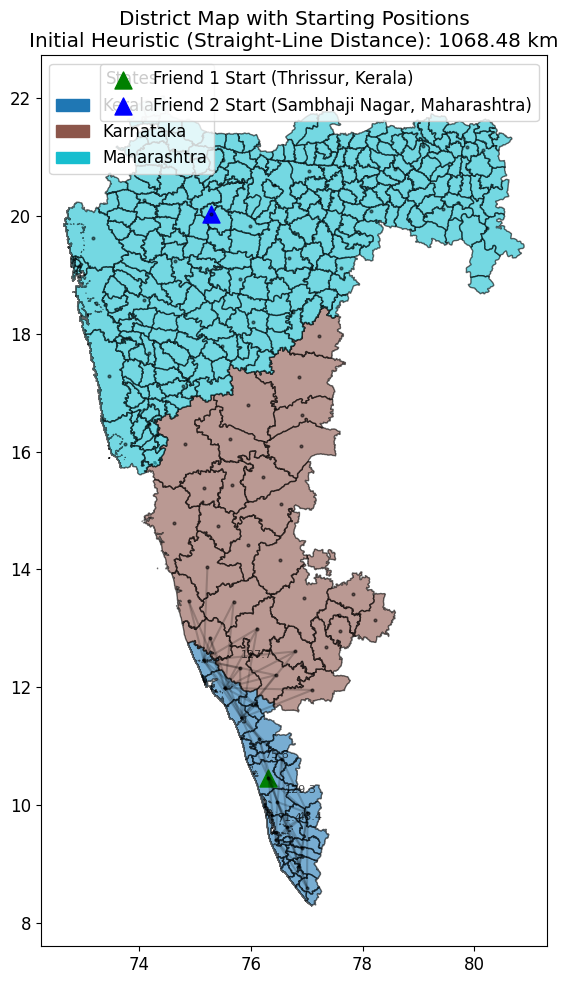


Running Greedy Best First Search...
Greedy Best First Search results:
Success: True
Path length: 6 steps
Path cost: 1247.08 km
Nodes generated: 372
Max frontier size: 367
Time taken: 0.0228 seconds

Running A* Search with straight-line heuristic...
A* Search results:
Success: True
Path length: 5 steps
Path cost: 1183.13 km
Nodes generated: 798
Max frontier size: 1329
Time taken: 0.0664 seconds
Debug - States in dataset: ['Kerala' 'Karnataka' 'Maharashtra']
Debug - Kerala districts: 14
Debug - Karnataka districts: 30
Debug - Maharashtra districts: 34
Plotted 14 districts for Kerala
Plotted 30 districts for Karnataka
Plotted 34 districts for Maharashtra
Total steps in path: 6
Meeting point found at step 5 in Bellary
Friend 1 path: ['Thrissur', 'Wayanad', 'Hassan', 'Chitradurga', 'Bellary']
Friend 2 path: ['Sambhaji Nagar', 'Bid', 'Solapur', 'Bagalkot', 'Koppal', 'Bellary']


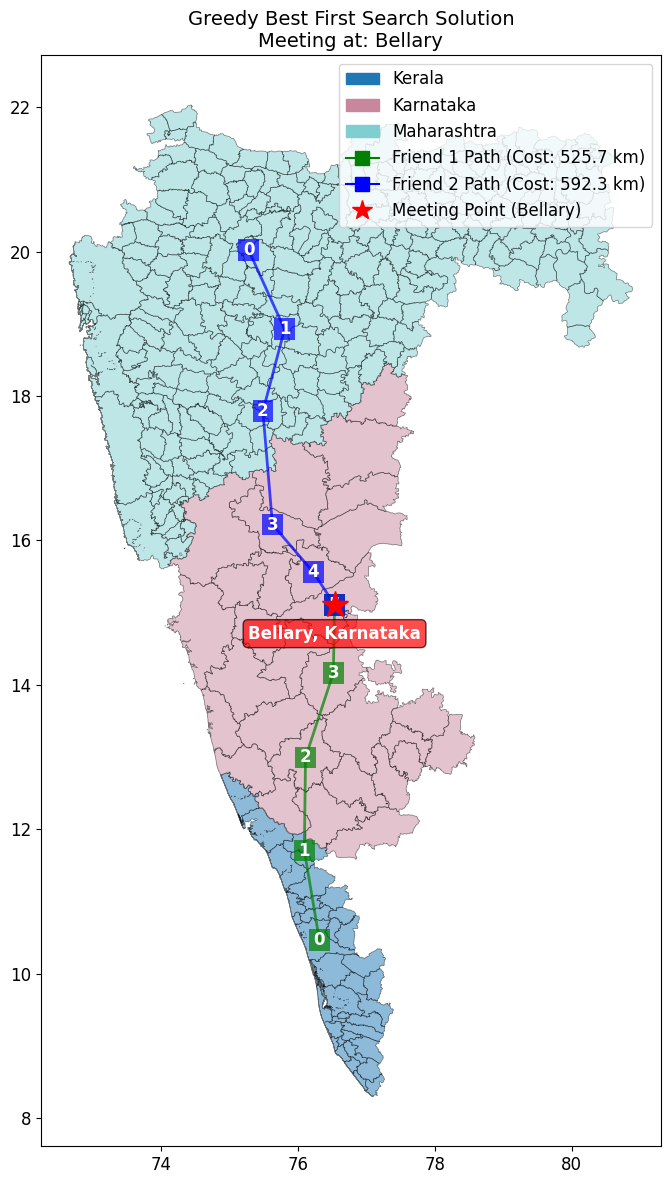

Debug - States in dataset: ['Kerala' 'Karnataka' 'Maharashtra']
Debug - Kerala districts: 14
Debug - Karnataka districts: 30
Debug - Maharashtra districts: 34
Plotted 14 districts for Kerala
Plotted 30 districts for Karnataka
Plotted 34 districts for Maharashtra
Total steps in path: 5
Meeting point found at step 4 in Dharwad
Friend 1 path: ['Thrissur', 'Kozhikode', 'Kasaragod', 'Shimoga', 'Dharwad']
Friend 2 path: ['Sambhaji Nagar', 'Bid', 'Solapur', 'Bagalkot', 'Dharwad']


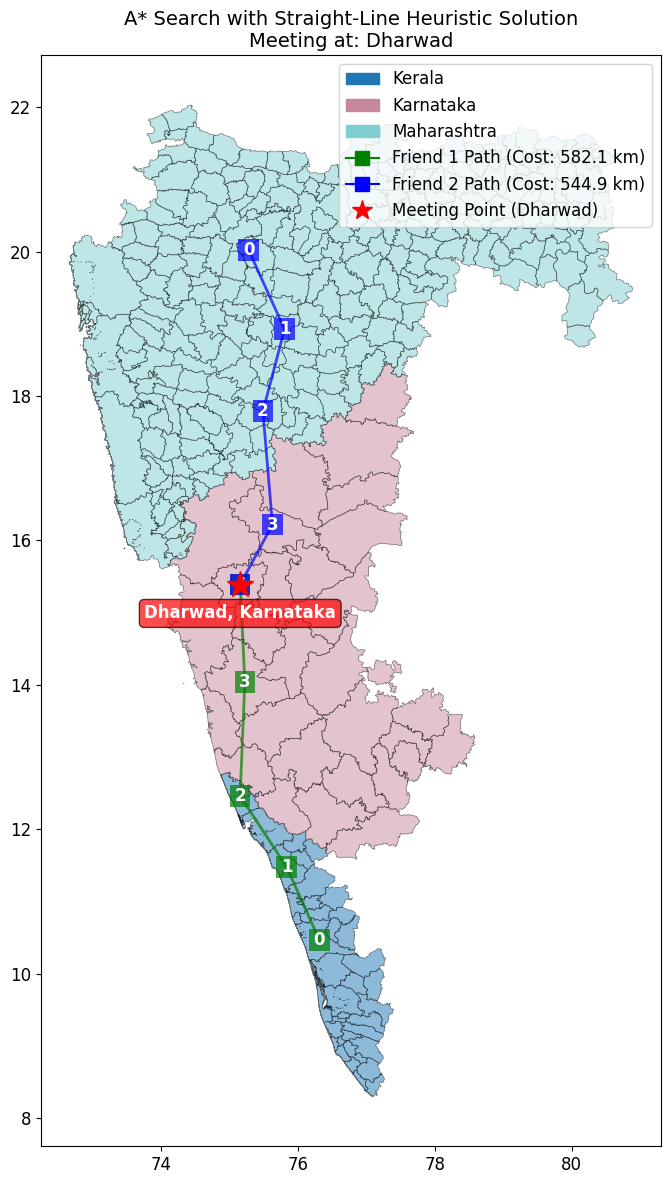


Running A* Search with road distance heuristic...
A* with Road Distance Heuristic results:
Success: True
Path length: 6 steps
Path cost: 1228.58 km
Nodes generated: 364
Max frontier size: 359
Time taken: 0.0117 seconds

Running A* Search with train route heuristic...
A* with Train Route Heuristic results:
Success: True
Path length: 6 steps
Path cost: 1247.08 km
Nodes generated: 372
Max frontier size: 367
Time taken: 0.0111 seconds
Debug - States in dataset: ['Kerala' 'Karnataka' 'Maharashtra']
Debug - Kerala districts: 14
Debug - Karnataka districts: 30
Debug - Maharashtra districts: 34
Plotted 14 districts for Kerala
Plotted 30 districts for Karnataka
Plotted 34 districts for Maharashtra
Total steps in path: 6
Meeting point found at step 5 in Bellary
Friend 1 path: ['Thrissur', 'Wayanad', 'Hassan', 'Chitradurga', 'Bellary']
Friend 2 path: ['Sambhaji Nagar', 'Bid', 'Solapur', 'Bijapur', 'Koppal', 'Bellary']


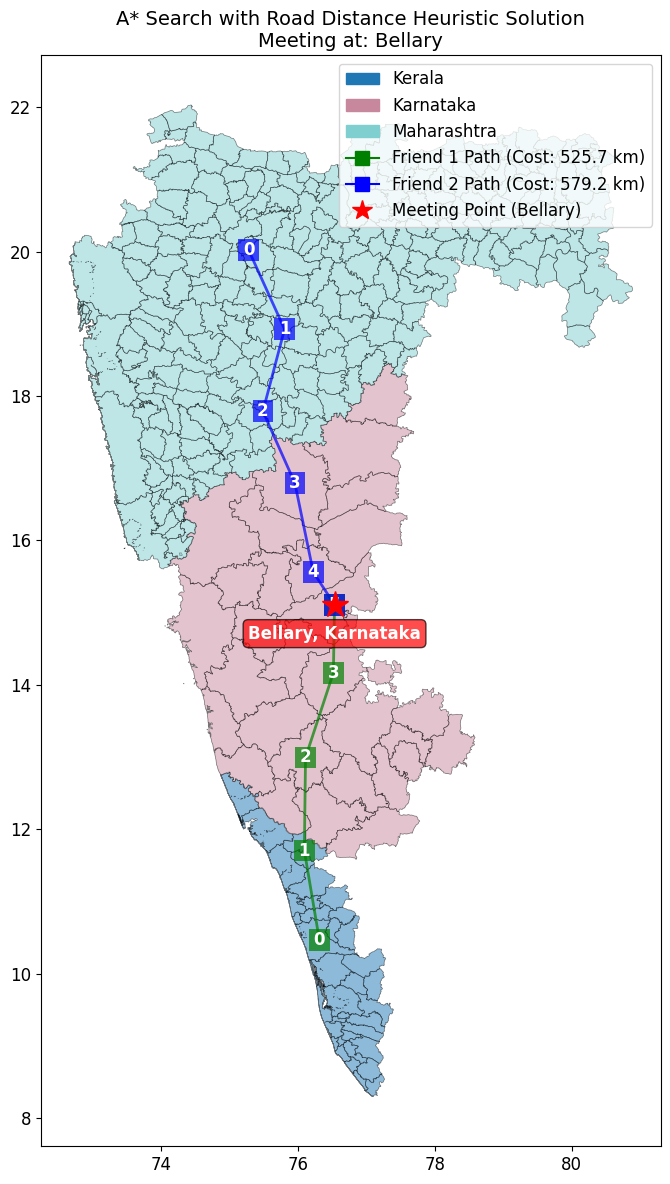

Debug - States in dataset: ['Kerala' 'Karnataka' 'Maharashtra']
Debug - Kerala districts: 14
Debug - Karnataka districts: 30
Debug - Maharashtra districts: 34
Plotted 14 districts for Kerala
Plotted 30 districts for Karnataka
Plotted 34 districts for Maharashtra
Total steps in path: 6
Meeting point found at step 5 in Bellary
Friend 1 path: ['Thrissur', 'Wayanad', 'Hassan', 'Chitradurga', 'Bellary']
Friend 2 path: ['Sambhaji Nagar', 'Bid', 'Solapur', 'Bagalkot', 'Koppal', 'Bellary']


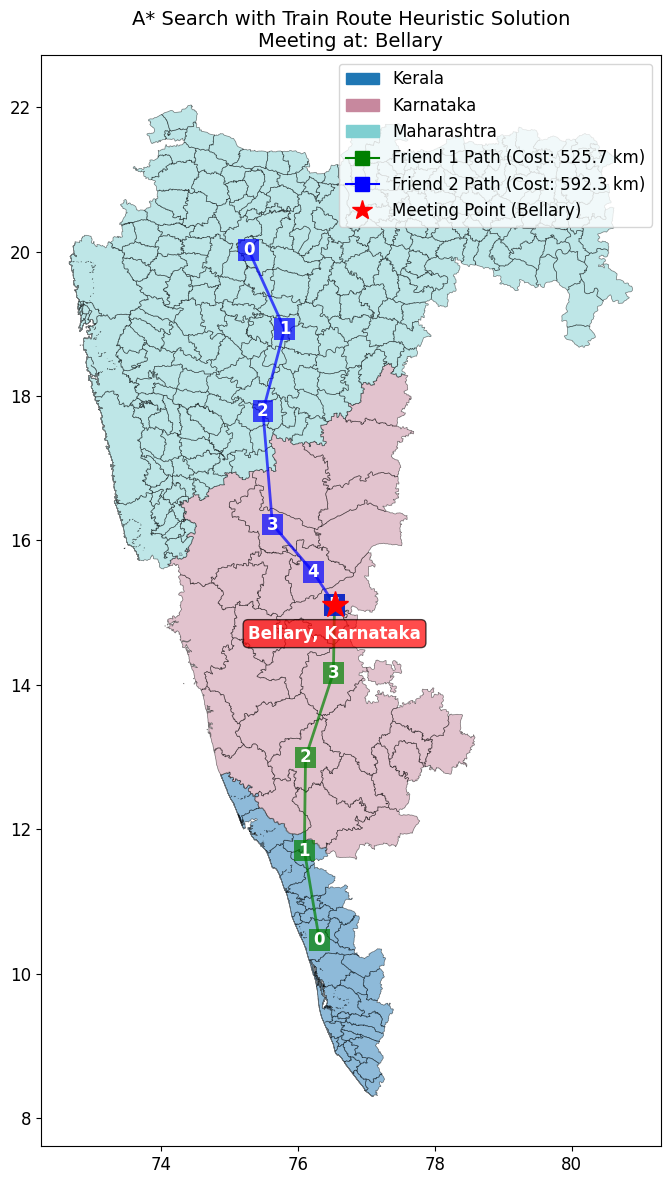


Algorithm Comparison:
                  Algorithm  Nodes Generated  Max Frontier Size  \
0  Greedy Best First Search              372                367   
1        A* (Straight Line)              798               1329   
2        A* (Road Distance)              364                359   
3          A* (Train Route)              372                367   

   Path Cost (km)  Time (sec)  
0     1247.081880    0.022827  
1     1183.130759    0.066369  
2     1228.581217    0.011696  
3     1247.081880    0.011085  


<ipython-input-29-8a8b79e96bd0>:226: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(comparison_table['Algorithm'], rotation=45, ha='right')
<ipython-input-29-8a8b79e96bd0>:232: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(comparison_table['Algorithm'], rotation=45, ha='right')
<ipython-input-29-8a8b79e96bd0>:238: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_xticklabels(comparison_table['Algorithm'], rotation=45, ha='right')


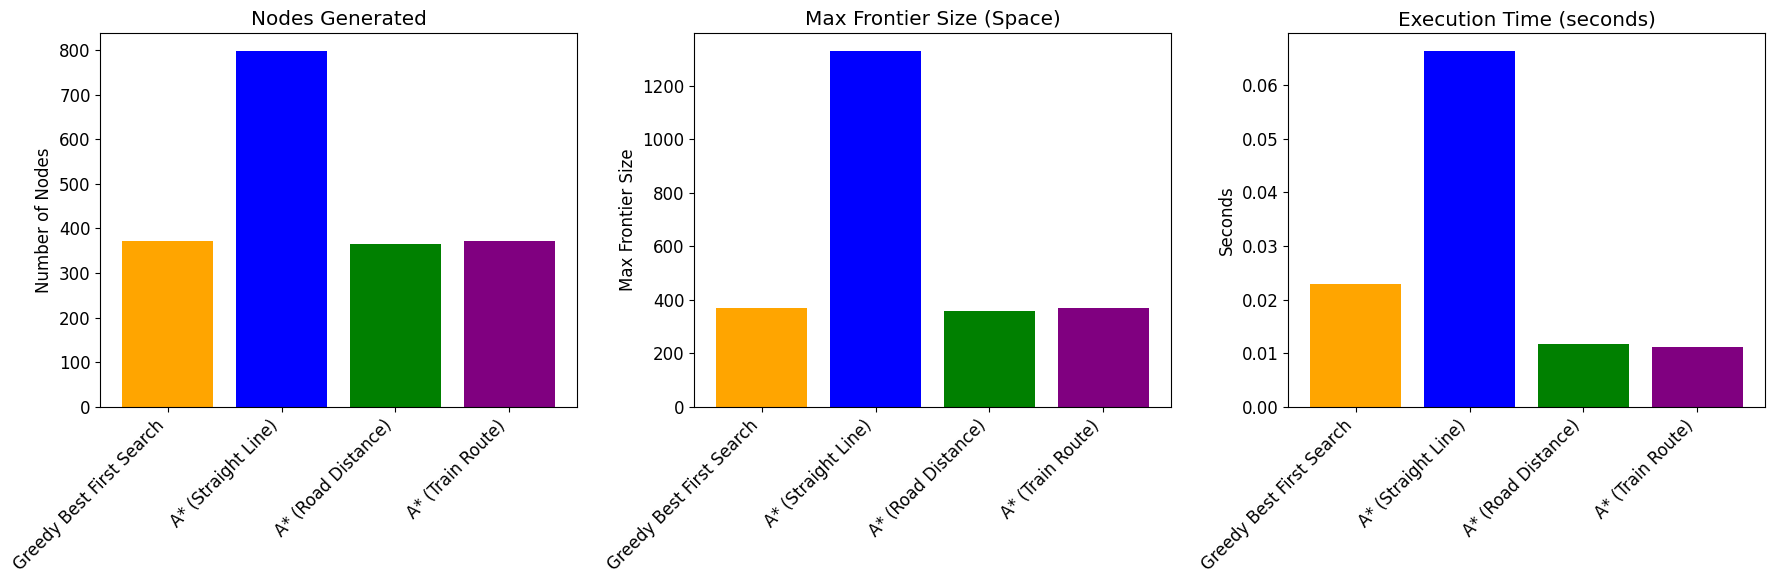


Analysis complete. Algorithm performance comparison saved as 'algorithm_performance_comparison.png'


In [ ]:
def main():
    print("Loading and preparing data...")
    combined_gdf = load_data()

    # Verify that all three states are present
    states = combined_gdf['st_nm'].unique()
    print(f"\nStates in dataset: {states}")

    # Make sure Karnataka is included
    if 'Karnataka' not in states:
        print("WARNING: Karnataka not found in states! This is likely a data loading issue.")
        print("Attempting to fix by trying alternative Karnataka GeoJSON file...")

        # Try to load Karnataka from the downloaded file explicitly
        try:
            karnataka_gdf = gpd.read_file('/Users/ashishpisey/Downloads/karnataka_district (1).json')
            # Add state name if not present
            karnataka_gdf['st_nm'] = 'Karnataka'
            print(f"Successfully loaded Karnataka from downloads: {len(karnataka_gdf)} districts")

            # Add to the combined GeoDataFrame
            combined_gdf = pd.concat([combined_gdf, karnataka_gdf])
            print(f"Updated states in dataset: {combined_gdf['st_nm'].unique()}")
        except Exception as e:
            print(f"Error loading Karnataka data from downloads: {e}")
            print("Please ensure the Karnataka GeoJSON file is correctly formatted.")

    # Select starting locations in different states
    friend1_start = "Thrissur"  # Kerala
    friend2_start = "Sambhaji Nagar"  # Maharashtra (new name for Aurangabad)

    # Check if friend1_start exists in the data
    if 'district' in combined_gdf.columns and friend1_start not in combined_gdf['district'].values:
        print(f"Warning: {friend1_start} not found in dataset.")
        kerala_districts = combined_gdf[combined_gdf['st_nm'] == 'Kerala']['district'].values
        if len(kerala_districts) > 0:
            friend1_start = kerala_districts[0]
            print(f"Using {friend1_start} as friend1_start instead")

    # Check if friend2_start exists in the data
    if 'district' in combined_gdf.columns and friend2_start not in combined_gdf['district'].values:
        print(f"Warning: {friend2_start} not found in dataset.")
        # Try various alternative names for Sambhaji Nagar/Aurangabad
        alternative_names = ["Aurangabad", "Chhatrapati Sambhajinagar", "Sambhajinagar"]
        found = False
        for alt_name in alternative_names:
            if alt_name in combined_gdf['district'].values:
                friend2_start = alt_name
                found = True
                print(f"Using {friend2_start} as friend2_start instead")
                break

        # If still not found, use any Maharashtra district
        if not found:
            maharashtra_districts = combined_gdf[combined_gdf['st_nm'] == 'Maharashtra']['district'].values
            if len(maharashtra_districts) > 0:
                friend2_start = maharashtra_districts[0]
                print(f"Using {friend2_start} as friend2_start instead")

    print("\nCreating city network...")
    print(f"Looking for districts: {friend1_start} and {friend2_start}")
    G = create_city_network(combined_gdf, required_districts=[friend1_start, friend2_start])

    print(f"\nSelected starting points:")
    print(f"Friend 1: {friend1_start} (Kerala)")
    print(f"Friend 2: {friend2_start} (Maharashtra)")

    # Initialize the problem for initial map visualization
    problem = MeetupProblem(G, friend1_start, friend2_start, algorithm_type='general')

    # Display the initial map with heuristic values
    fig, ax = plt.subplots(figsize=(15, 10))

    # Create a categorical color map for states
    unique_states = combined_gdf['st_nm'].unique()
    state_colors = plt.cm.tab10(np.linspace(0, 1, len(unique_states)))
    state_color_dict = dict(zip(unique_states, state_colors))

    # Plot all districts with distinct colors by state
    for state_name in unique_states:
        state_gdf = combined_gdf[combined_gdf['st_nm'] == state_name]
        state_gdf.plot(ax=ax, alpha=0.6, edgecolor='black',
                      color=state_color_dict[state_name],
                      label=state_name)

    # Plot district centers
    for node, attrs in G.nodes(data=True):
        plt.plot(attrs['pos'][0], attrs['pos'][1], 'ko', markersize=2, alpha=0.5)

    # Highlight starting positions
    friend1_data = combined_gdf[combined_gdf['district'] == friend1_start].iloc[0]
    friend2_data = combined_gdf[combined_gdf['district'] == friend2_start].iloc[0]
    ax.scatter(friend1_data['lon'], friend1_data['lat'], c='green', s=150, marker='^',
              label=f'Friend 1 Start ({friend1_start}, {friend1_data["st_nm"]})')
    ax.scatter(friend2_data['lon'], friend2_data['lat'], c='blue', s=150, marker='^',
              label=f'Friend 2 Start ({friend2_start}, {friend2_data["st_nm"]})')

    # Draw some example edges with costs
    edge_count = 0
    for edge in G.edges():
        if edge_count > 60:  # Limit to avoid overcrowding
            break
        node1, node2 = edge
        pos1 = G.nodes[node1]['pos']
        pos2 = G.nodes[node2]['pos']

        # Draw edge
        plt.plot([pos1[0], pos2[0]], [pos1[1], pos2[1]], 'k-', alpha=0.2)

        # Draw cost at midpoint
        mid_x = (pos1[0] + pos2[0]) / 2
        mid_y = (pos1[1] + pos2[1]) / 2

        # Only show some costs to avoid clutter
        if edge_count % 15 == 0:
            cost = G.edges[edge]['weight']
            plt.text(mid_x, mid_y, f"{cost:.1f}", fontsize=8, alpha=0.7)

        edge_count += 1

    # Calculate initial heuristic value
    initial_heuristic = problem.heuristic_straight_line(problem.start)

    # Create legend for state colors
    state_patches = [mpatches.Patch(color=state_color_dict[state], label=state) for state in unique_states]

    # First legend for state colors
    first_legend = ax.legend(handles=state_patches, loc='upper left', title='States')
    ax.add_artist(first_legend)

    # Second legend for start positions
    ax.legend(loc='upper right')

    plt.title(f'District Map with Starting Positions\nInitial Heuristic (Straight-Line Distance): {initial_heuristic:.2f} km')
    plt.tight_layout()
    plt.savefig('initial_map.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Create separate problem instances for each algorithm type to ensure different paths
    greedy_problem = MeetupProblem(G, friend1_start, friend2_start, algorithm_type='greedy')
    astar_straight_problem = MeetupProblem(G, friend1_start, friend2_start, algorithm_type='astar_straight')
    astar_road_problem = MeetupProblem(G, friend1_start, friend2_start, algorithm_type='astar_road')
    astar_train_problem = MeetupProblem(G, friend1_start, friend2_start, algorithm_type='astar_train')

    print("\nRunning Greedy Best First Search...")
    greedy_result = greedy_best_first_search(greedy_problem)

    print(f"Greedy Best First Search results:")
    print(f"Success: {greedy_result['success']}")
    if greedy_result['success']:
        print(f"Path length: {len(greedy_result['path'])} steps")
        print(f"Path cost: {greedy_result['path_cost']:.2f} km")
    print(f"Nodes generated: {greedy_result['nodes_generated']}")
    print(f"Max frontier size: {greedy_result['max_frontier_size']}")
    print(f"Time taken: {greedy_result['time_taken']:.4f} seconds")

    print("\nRunning A* Search with straight-line heuristic...")
    astar_result = a_star_search(astar_straight_problem)

    print(f"A* Search results:")
    print(f"Success: {astar_result['success']}")
    if astar_result['success']:
        print(f"Path length: {len(astar_result['path'])} steps")
        print(f"Path cost: {astar_result['path_cost']:.2f} km")
    print(f"Nodes generated: {astar_result['nodes_generated']}")
    print(f"Max frontier size: {astar_result['max_frontier_size']}")
    print(f"Time taken: {astar_result['time_taken']:.4f} seconds")

    # Visualize solutions if successful
    if greedy_result['success']:
        visualize_solution(combined_gdf, G, friend1_start, friend2_start, greedy_result['path'],
                        "Greedy Best First Search Solution")

    if astar_result['success']:
        visualize_solution(combined_gdf, G, friend1_start, friend2_start, astar_result['path'],
                        "A* Search with Straight-Line Heuristic Solution")

    # Alternative heuristics
    print("\nRunning A* Search with road distance heuristic...")
    astar_road_result = a_star_search(astar_road_problem, astar_road_problem.heuristic_road_distance)

    print(f"A* with Road Distance Heuristic results:")
    print(f"Success: {astar_road_result['success']}")
    if astar_road_result['success']:
        print(f"Path length: {len(astar_road_result['path'])} steps")
        print(f"Path cost: {astar_road_result['path_cost']:.2f} km")
    print(f"Nodes generated: {astar_road_result['nodes_generated']}")
    print(f"Max frontier size: {astar_road_result['max_frontier_size']}")
    print(f"Time taken: {astar_road_result['time_taken']:.4f} seconds")

    print("\nRunning A* Search with train route heuristic...")
    astar_train_result = a_star_search(astar_train_problem, astar_train_problem.heuristic_train_route)

    print(f"A* with Train Route Heuristic results:")
    print(f"Success: {astar_train_result['success']}")
    if astar_train_result['success']:
        print(f"Path length: {len(astar_train_result['path'])} steps")
        print(f"Path cost: {astar_train_result['path_cost']:.2f} km")
    print(f"Nodes generated: {astar_train_result['nodes_generated']}")
    print(f"Max frontier size: {astar_train_result['max_frontier_size']}")
    print(f"Time taken: {astar_train_result['time_taken']:.4f} seconds")

    # Visualize solutions for alternative heuristics
    if astar_road_result['success']:
        visualize_solution(combined_gdf, G, friend1_start, friend2_start, astar_road_result['path'],
                        "A* Search with Road Distance Heuristic Solution")

    if astar_train_result['success']:
        visualize_solution(combined_gdf, G, friend1_start, friend2_start, astar_train_result['path'],
                        "A* Search with Train Route Heuristic Solution")

    # Create comparison table
    comparison_table = create_comparison_table(greedy_result, astar_result, astar_road_result, astar_train_result)
    print("\nAlgorithm Comparison:")
    print(comparison_table)

    # Plot performance comparison
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

    # Define colors for each algorithm
    algorithm_colors = ['orange', 'blue', 'green', 'purple']

    # Nodes generated comparison
    ax1.bar(comparison_table['Algorithm'], comparison_table['Nodes Generated'], color=algorithm_colors)
    ax1.set_title('Nodes Generated')
    ax1.set_xticklabels(comparison_table['Algorithm'], rotation=45, ha='right')
    ax1.set_ylabel('Number of Nodes')

    # Space comparison (max frontier size)
    ax2.bar(comparison_table['Algorithm'], comparison_table['Max Frontier Size'], color=algorithm_colors)
    ax2.set_title('Max Frontier Size (Space)')
    ax2.set_xticklabels(comparison_table['Algorithm'], rotation=45, ha='right')
    ax2.set_ylabel('Max Frontier Size')

    # Time comparison
    ax3.bar(comparison_table['Algorithm'], comparison_table['Time (sec)'], color=algorithm_colors)
    ax3.set_title('Execution Time (seconds)')
    ax3.set_xticklabels(comparison_table['Algorithm'], rotation=45, ha='right')
    ax3.set_ylabel('Seconds')

    plt.tight_layout()
    plt.savefig('algorithm_performance_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("\nAnalysis complete. Algorithm performance comparison saved as 'algorithm_performance_comparison.png'")

if __name__ == "__main__":
    main()